<a href="https://colab.research.google.com/github/sudarshan-khot/Volumetric-Segmentation-and-Stroke-Triage-via-Transformers/blob/main/Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1
!pip install -q -U segmentation-models-pytorch albumentations pandas opencv-python-headless monai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.

In [ ]:
# Cell 2
import os
import re
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from google.colab import drive

# Ensure reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Cell 3
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 4
# UPDATE THESE PATHS to include the base Segmentation folder to find all splits
BASE_PATH = "/content/drive/MyDrive/AI-Based_Infarct_Volume_Estimation_from_Non-Contrast_CT_for_Acute_Anterior_Circulation_Stroke"
# We search the whole Segmentation folder now
SEG_ROOT = f"{BASE_PATH}/Segmentation"
IMG_SEARCH_PATH = SEG_ROOT
MASK_PATH = f"{SEG_ROOT}/train/masks"

In [ ]:
import os
import pandas as pd
import re
import cv2

def parse_filename(filename, parent_folder=None):
    """
    Extracts Patient ID and Slice ID.
    """
    match = re.search(r'(\d+)', filename)
    s_id = int(match.group(1)) if match else 0
    p_id = str(parent_folder) if parent_folder else "Unknown"
    return p_id, s_id

def create_manifest_with_split(base_path):
    import os
    import pandas as pd
    data = []

    seg_root = os.path.join(base_path, "Segmentation")
    splits = ['train', 'val', 'test']

    for split in splits:
        img_dir = os.path.join(seg_root, split, "images")
        mask_dir = os.path.join(seg_root, split, "masks")

        if not os.path.exists(img_dir): continue

        for entry in os.scandir(img_dir):
            if entry.is_dir():
                patient_id = entry.name
                for img_file in sorted(os.listdir(entry.path)):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        full_img_path = os.path.join(entry.path, img_file)
                        full_mask_path = os.path.join(mask_dir, patient_id, img_file)

                        data.append({
                            'filename': img_file,
                            'patient_id': patient_id,
                            'slice_id': int(''.join(filter(str.isdigit, img_file)) or 0),
                            'full_path': full_img_path,
                            'mask_path': full_mask_path,
                            'split': split
                        })

    df = pd.DataFrame(data)

    split_csv_path = os.path.join(base_path, "Segmentation", "seg_split_manifest.csv")
    if os.path.exists(split_csv_path):
        split_df = pd.read_csv(split_csv_path, dtype={'patient': str})
        df = df.merge(split_df, left_on=['patient_id', 'filename'], right_on=['patient', 'filename'], how='left', suffixes=('', '_csv'))
        if 'split_csv' in df.columns:
            df['split'] = df['split_csv'].combine_first(df['split'])
            df.drop(columns=['patient', 'split_csv'], inplace=True, errors='ignore')

    return df.sort_values(['patient_id', 'slice_id']).reset_index(drop=True)

# Generate manifest scanning selectively across dataset
full_df = create_manifest_with_split(BASE_PATH)

# Get sample image dimensions
sample_img = cv2.imread(full_df.iloc[0]['full_path'])
h, w, c = sample_img.shape

print("Please include clear and specific details about the dataset used to train your model. This should explicitly state all dimensions, for example:")
print(f"\t• For image datasets: {len(full_df)} images (Dimensions: {h}x{w})")
print(f"\t• Data Split Breakdown: {full_df['split'].value_counts().to_dict()}")
print(f"\t• For CSV files: {full_df.shape[0]} rows, {full_df.shape[1]} columns")

Please include clear and specific details about the dataset used to train your model. This should explicitly state all dimensions, for example:
	• For image datasets: 250 images (Dimensions: 650x650)
	• Data Split Breakdown: {'train': 208, 'val': 42}
	• For CSV files: 250 rows, 6 columns


--- Data Diagnostic for: 15.jpg ---
Storage Format: jpg
Shape: (650, 650)
Min Pixel Value: 0
Max Pixel Value: 255
Mean Pixel Value: 61.78

VERDICT: This is a standard 8-bit PNG (0-255).


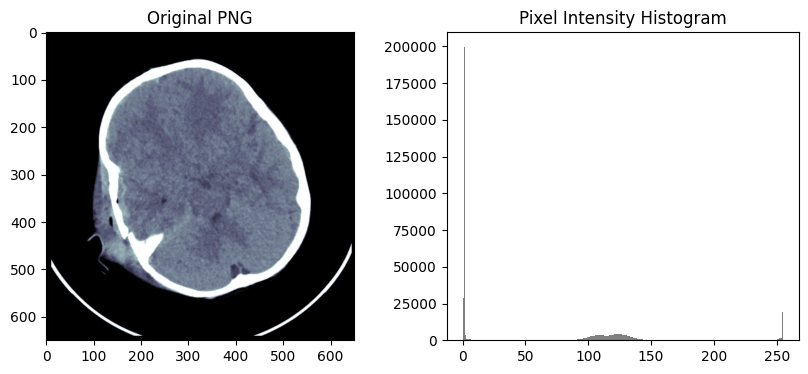

In [ ]:
# Cell 3.5: Clinical Data Diagnostic
import matplotlib.pyplot as plt

def diagnose_input_data(df, idx=0):
    sample_path = df.iloc[idx]['full_path']
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

    print(f"--- Data Diagnostic for: {os.path.basename(sample_path)} ---")
    print(f"Storage Format: {sample_path.split('.')[-1]}")
    print(f"Shape: {img.shape}")
    print(f"Min Pixel Value: {img.min()}")
    print(f"Max Pixel Value: {img.max()}")
    print(f"Mean Pixel Value: {img.mean():.2f}")

    if img.max() <= 255 and img.min() >= 0:
        if img.max() > 100: # Typical for a viewable PNG
            print("\nVERDICT: This is a standard 8-bit PNG (0-255).")
        else:
            print("\nVERDICT: Unusual range. Possibly low-contrast.")
    else:
        print("\nVERDICT: High-bit depth detected. This might be raw HU data.")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='bone')
    plt.title("Original PNG")

    plt.subplot(1, 2, 2)
    plt.hist(img.ravel(), bins=256, color='gray')
    plt.title("Pixel Intensity Histogram")
    plt.show()

# Run the check
diagnose_input_data(full_df, idx=10)

In [ ]:
# Download Swin UNETR BTCV pretrained weights from MONAI Model Zoo
import urllib.request
import os

WEIGHTS_DIR = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan"
WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, "swin_unetr_btcv_weights.pt")

if not os.path.exists(WEIGHTS_PATH):
    url = "https://github.com/Project-MONAI/MONAI-extra-test-data/releases/download/0.8.1/swin_unetr.base_5000ep_f48_lr2e-4_pretrained.pt"
    print("Downloading Swin UNETR pretrained weights (~400MB)...")
    urllib.request.urlretrieve(url, WEIGHTS_PATH)
    print(f"Download complete: {WEIGHTS_PATH}")
else:
    print(f"Weights already present: {WEIGHTS_PATH}")

Download complete: /content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/swin_unetr_btcv_weights.pt


In [ ]:
# --- RUN THIS CELL TO CLEAR MEMORY ---
import gc
# Delete old model and clear GPU cache
if 'model' in locals():
    del model
torch.cuda.empty_cache()
gc.collect()

2258

In [ ]:
# # Cell 6
# from monai.networks.nets import DynUNet

# model = DynUNet(
#     spatial_dims=2,
#     in_channels=5, # Or 5 if you increase stack
#     out_channels=1,
#     kernel_size=[3, 3, 3, 3, 3],
#     strides=[1, 2, 2, 2, 2],
#     upsample_kernel_size=[2, 2, 2, 2],
#     filters=[64, 128, 256, 512, 1024],
# ).to(device)

# # Spatial Dropout: force-disconnects 20% of conv neurons to prevent memorization
# # on a small 208-image dataset. Targets only Conv2d layers that expose a dropout attribute.
# for module in model.modules():
#     if isinstance(module, nn.Conv2d):
#         if hasattr(module, 'dropout'):
#             module.dropout = nn.Dropout2d(p=0.2)

# # Tversky alpha=0.3, beta=0.7: heavily penalizes False Negatives (missed infarcts)
# # to force the model to prioritize recall over precision
# criterion_tversky = smp.losses.TverskyLoss(mode='binary', alpha=0.3, beta=0.7, from_logits=True)
# criterion_focal = smp.losses.FocalLoss(mode='binary')

# def criterion(output, target):
#     # 70% Tversky (recall-focused) + 30% Focal (hard pixel focus)
#     return 0.3 * criterion_focal(output, target) + 0.7 * criterion_tversky(output, target)

# # Lower initial LR (5e-5) prevents overshooting the subtle NCCT gradient landscape
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

# # CosineAnnealingWarmRestarts: oscillates LR to escape local minima
# # T_0=10 means first restart after 10 epochs, T_mult=2 doubles the cycle each time
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=10, T_mult=2, eta_min=1e-7
# )

# transforms = A.Compose([
#     A.Resize(256, 256),
#     # Anatomy-mimicking distortions:
#     A.ElasticTransform(p=0.3, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
#     A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5), # Mild warping
#     # A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(p=0.2),
#     A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
#     ToTensorV2(),
# ])


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/tmp/ipykernel_2720/3479728416.py:42: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.3, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# Cell 6 - Round 2: Swin UNETR Fine-Tuning
import torch
import torch.nn as nn
from monai.networks.nets import SwinUNETR
import monai.losses

# --- Model ---
# img_size was removed in MONAI >= 1.5. The forward pass now validates dimensions.
# Requirement: spatial dims must be divisible by 32. Our 256x256 input satisfies this.
# in_channels=5 to match the 5-slice axial stack.
# feature_size=48 is required to match the BTCV pretrained bundle weights.
model = SwinUNETR(
    in_channels=5,
    out_channels=1,
    feature_size=48,
    use_checkpoint=True,   # Gradient checkpointing: reduces VRAM use, mandatory for Colab T4
    spatial_dims=2,
).to(device)

# --- Load pretrained BTCV weights (transfer learning) ---
PRETRAINED_WEIGHTS = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/swin_unetr_btcv_weights.pt"
try:
    # weights_only=False required: MONAI checkpoints contain numpy scalars (PyTorch 2.6)
    raw_ckpt = torch.load(PRETRAINED_WEIGHTS, map_location=device, weights_only=False)

    # Confirmed structure: {'epoch': ..., 'best_acc': ..., 'state_dict': {...}}
    # Must unwrap via 'state_dict' key before comparing with model's state_dict.
    state_dict = raw_ckpt.get('state_dict', raw_ckpt)

    # Partial load: only transfer layers whose key AND shape both match.
    # Expected: ~97/159 layers match (transformer attention/FFN linear layers).
    # Non-matching: patch_embed (in_channels 3->5), Conv3d->Conv2d spatial layers.
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in state_dict.items()
                       if k in model_dict and v.shape == model_dict[k].shape}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)
    print(f"Pretrained weights loaded: {len(pretrained_dict)}/{len(model_dict)} layers matched.")
except Exception as e:
    print(f"Could not load pretrained weights, starting from scratch: {e}")

# --- Three-Tier Loss for F1/Dice Maximisation ---
# Tversky (alpha=0.1) aggressively punishes False Negatives (missed infarcts)
# Dice directly optimises the global F1/Dice score
# Focal focuses gradient on hard, boundary pixels
criterion_dice    = monai.losses.DiceLoss(sigmoid=True)
criterion_focal   = monai.losses.FocalLoss(gamma=2.0, reduction='mean')
criterion_tversky = monai.losses.TverskyLoss(alpha=0.1, beta=0.9, sigmoid=True)

def criterion(pred, target):
    return (0.4 * criterion_dice(pred, target) +
            0.4 * criterion_tversky(pred, target) +
            0.2 * criterion_focal(pred, target))

# --- Optimizer & Scheduler ---
# Lower LR for fine-tuning pretrained transformer weights (do not blow up attention maps)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-8
)

# --- Augmentation (unchanged from Round 1, ShiftScaleRotate replaced with Affine) ---
transforms = A.Compose([
    A.Resize(256, 256),
    A.ElasticTransform(p=0.3, alpha=120, sigma=120 * 0.05),
    # ShiftScaleRotate is deprecated in Albumentations; Affine is the direct replacement
    A.Affine(scale=(0.95, 1.05), translate_percent=0.05, rotate=(-10, 10), p=0.5),
    # A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2(),
])


Pretrained weights loaded: 97/159 layers matched.


In [ ]:
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

class Stroke25DDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def apply_window(self, img):
        # Ensure it's in the correct uint8 format for Albumentations.
        # return img.astype(np.uint8)

        # Apply CLAHE per single-channel slice here, before stacking.
        # A.CLAHE cannot handle the 5-channel stack, so it must happen at this stage.
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        img = clahe.apply(img.astype(np.uint8))
        return img

    def get_neighbors(self, idx, offset):
        """Fetches neighbor slice path safely preventing cross-patient matching."""
        curr_row = self.df.iloc[idx]
        target_idx = idx + offset

        # Out of bounds check
        if target_idx < 0 or target_idx >= len(self.df):
            return curr_row['full_path']

        target_row = self.df.iloc[target_idx]
        # Ensure the neighbor belongs to the same patient
        if target_row['patient_id'] == curr_row['patient_id']:
            return target_row['full_path']
        return curr_row['full_path']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Fetch 5 slices: prev-2, prev-1, curr, next+1, next+2
        p_minus2 = self.get_neighbors(idx, -2)
        p_minus1 = self.get_neighbors(idx, -1)
        p_plus1 = self.get_neighbors(idx, 1)
        p_plus2 = self.get_neighbors(idx, 2)

        img_m2 = cv2.imread(p_minus2, cv2.IMREAD_GRAYSCALE)
        img_m1 = cv2.imread(p_minus1, cv2.IMREAD_GRAYSCALE)
        img_curr = cv2.imread(row['full_path'], cv2.IMREAD_GRAYSCALE)
        img_p1 = cv2.imread(p_plus1, cv2.IMREAD_GRAYSCALE)
        img_p2 = cv2.imread(p_plus2, cv2.IMREAD_GRAYSCALE)

        # Stack into 5 channels
        stack = np.stack([
            self.apply_window(img_m2),
            self.apply_window(img_m1),
            self.apply_window(img_curr),
            self.apply_window(img_p1),
            self.apply_window(img_p2)
        ], axis=-1)

        # Read the explicit mask path from the dataframe
        if 'mask_path' in row and pd.notna(row['mask_path']):
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is None:
                mask = np.zeros(stack.shape[:2], dtype=np.float32)
            else:
                mask = (mask > 0).astype(np.float32)
        else:
            mask = np.zeros(stack.shape[:2], dtype=np.float32)

        if self.transform:
            augmented = self.transform(image=stack, mask=mask)
            image_tensor = augmented['image']
            mask_tensor = augmented['mask'].unsqueeze(0)
        else:
            image_tensor = torch.from_numpy(stack.transpose(2, 0, 1)).float() / 255.0
            mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        return image_tensor, mask_tensor


In [ ]:
# Cell 8
print("Value counts for 'split' column:")
print(full_df['split'].value_counts())

print("\nRows in train_df:", len(train_df))
print("Rows in val_df:", len(val_df))

Value counts for 'split' column:
split
train    208
val       42
Name: count, dtype: int64

Rows in train_df: 208
Rows in val_df: 42


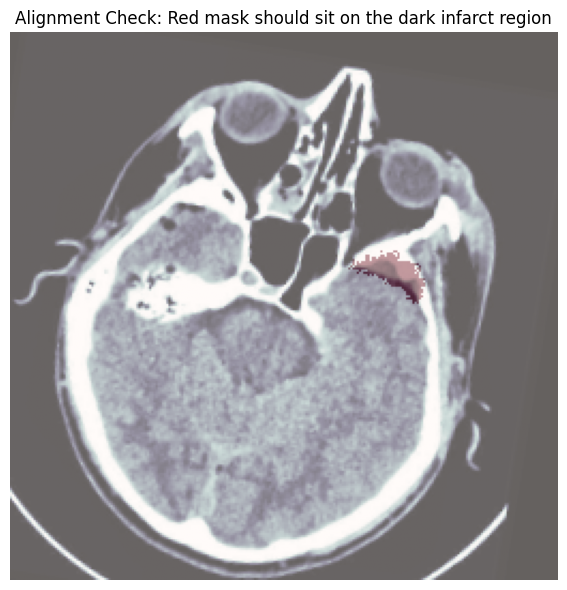

In [ ]:


# Mask Alignment Visual Check
# Pick index 5 or any index you know contains a stroke slice

train_ds = Stroke25DDataset(train_df, transform=transforms)
val_ds = Stroke25DDataset(val_df, transform=transforms)

image, mask = train_ds[1]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image[1].numpy(), cmap='bone')          # Middle channel = current slice
ax.imshow(mask[0].numpy(), cmap='Reds', alpha=0.4) # Overlay mask in red
ax.set_title("Alignment Check: Red mask should sit on the dark infarct region")
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os
CHECKPOINT_DIR = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints"
old_ckpt = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")
old_best = os.path.join(CHECKPOINT_DIR, "best_segmenter.pt")

if os.path.exists(old_ckpt):
    os.remove(old_ckpt)
    print("Deleted incompatible latest_checkpoint.pt")
if os.path.exists(old_best):
    os.remove(old_best)
    print("Deleted incompatible best_segmenter.pt")


In [ ]:
# Cell 9
import os

# --- 1. Dataset & Loader Initialization ---
train_ds = Stroke25DDataset(train_df, transform=transforms)
val_ds = Stroke25DDataset(val_df, transform=transforms)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

# --- 2. Checkpoint Config ---
CHECKPOINT_DIR = "/content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pt")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_segmenter.pt")

# --- 3. Function Definitions ---
def train_epoch(model, loader, opt, loss_fn):
    if len(loader) == 0:
        return 0.0
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_epoch(model, loader, loss_fn):
    if len(loader) == 0:
        return 0.0, 0.0
    model.eval()
    val_loss = 0
    dice_scores = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            val_loss += loss.item()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            intersection = (preds * y).sum()
            dice = (2. * intersection) / (preds.sum() + y.sum() + 1e-7)
            dice_scores.append(dice.item())
    return val_loss / len(loader), np.mean(dice_scores)

def save_checkpoint(epoch, model, optimizer, scheduler, best_dice, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_dice': float(best_dice),  # Cast to Python float to avoid numpy scalar pickling issue
    }, path)
    print(f"  Checkpoint saved at epoch {epoch} -> {path}")

def load_checkpoint(path, model, optimizer, scheduler):
    if os.path.exists(path):
        # weights_only=False required because checkpoint contains optimizer/scheduler state
        checkpoint = torch.load(path, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_dice = checkpoint['best_dice']
        print(f"Resumed from epoch {checkpoint['epoch']} | Best Dice so far: {best_dice:.4f}")
        return start_epoch, best_dice
    print("No checkpoint found. Starting fresh.")
    return 1, 0.0

# --- 4. Safety Check ---
train_pts = set(train_df['patient_id'])
val_pts = set(val_df['patient_id'])
overlap = train_pts.intersection(val_pts)
if overlap:
    print(f"CRITICAL ERROR: Data Leakage detected for patients: {overlap}")
else:
    print("Data Split is Clean: No patient overlap.")

# --- 5. Execution Loop with Early Stopping ---
if not train_df.empty:
    EPOCHS = 200
    EARLY_STOP_PATIENCE = 20  # Stop if no Dice improvement for 15 epochs
    epochs_without_improvement = 0

    start_epoch, best_dice = load_checkpoint(CHECKPOINT_PATH, model, optimizer, scheduler)

    for epoch in range(start_epoch, EPOCHS + 1):
        avg_train_loss = train_epoch(model, train_loader, optimizer, criterion)
        avg_val_loss, avg_dice = validate_epoch(model, val_loader, criterion)
        # CosineAnnealingWarmRestarts uses epoch index, not metric value
        scheduler.step(epoch - 1 + (len(train_loader) / len(train_loader)))
        # Simplified form — call once per epoch at epoch boundary:
        scheduler.step(epoch)

        print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_dice:.4f}")

        if avg_dice > best_dice:
            best_dice = avg_dice
            epochs_without_improvement = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"  Best model updated (Dice: {best_dice:.4f}) -> {BEST_MODEL_PATH}")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement. Patience: {epochs_without_improvement}/{EARLY_STOP_PATIENCE}")

        # if epoch % 5 == 0:
        #     save_checkpoint(epoch, model, optimizer, scheduler, best_dice, CHECKPOINT_PATH)

        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}. Best Val Dice: {best_dice:.4f}")
            break

    print(f"\nTraining complete. Best Validation Dice: {best_dice:.4f}")
else:
    print("Train dataframe is empty.")


Data Split is Clean: No patient overlap.
No checkpoint found. Starting fresh.
Epoch 1/200 | Train Loss: 0.7933 | Val Loss: 0.7944 | Val Dice: 0.0379
  Best model updated (Dice: 0.0379) -> /content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints/best_segmenter.pt
Epoch 2/200 | Train Loss: 0.7821 | Val Loss: 0.7850 | Val Dice: 0.0567
  Best model updated (Dice: 0.0567) -> /content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints/best_segmenter.pt
Epoch 3/200 | Train Loss: 0.7754 | Val Loss: 0.7791 | Val Dice: 0.0680
  Best model updated (Dice: 0.0680) -> /content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints/best_segmenter.pt
Epoch 4/200 | Train Loss: 0.7701 | Val Loss: 0.7735 | Val Dice: 0.0795
  Best model updated (Dice: 0.0795) -> /content/drive/MyDrive/Stroke_Infarct_Volume_Sudarshan/checkpoints/best_segmenter.pt
Epoch 5/200 | Train Loss: 0.7649 | Val Loss: 0.7693 | Val Dice: 0.0905
  Best model updated (Dice: 0.0905) -> /content/drive/MyDrive/Stroke_In

In [ ]:
import scipy.ndimage as ndimage

def clean_mask(mask_np, min_size=50):
    """Removes small speckle noise from binary prediction mask."""
    labeled, num_features = ndimage.label(mask_np)
    for i in range(1, num_features + 1):
        if np.sum(labeled == i) < min_size:
            mask_np[labeled == i] = 0
    return mask_np

def predict_with_tta(model, img_tensor):
    """
    Test-Time Augmentation: predict on 4 views and average probabilities.
    Original, H-Flip, V-Flip, and H+V Flip.
    """
    model.eval()
    with torch.no_grad():
        p_orig  = torch.sigmoid(model(img_tensor))
        p_hflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[3])))
        p_vflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[2])))
        p_hvflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[2, 3])))
        avg_prob = (p_orig + p_hflip + p_vflip + p_hvflip) / 4.0
    return avg_prob

def get_infarct_volume(model, dataset, patient_id, slice_thickness_mm=5.0, pixel_spacing_mm=0.5):
    """
    Calculates total infarct volume in mL for a patient.
    Uses TTA for stable predictions and post-processing to remove speckle noise.
    """
    model.eval()
    patient_df = dataset.df[dataset.df['patient_id'] == patient_id].reset_index(drop=True)
    total_pixels = 0

    for i in range(len(patient_df)):
        img_tensor = dataset[i][0].unsqueeze(0).to(device)

        # TTA-averaged probability map
        avg_prob = predict_with_tta(model, img_tensor)
        mask_np = (avg_prob.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

        # Remove isolated speckle predictions smaller than 50 pixels
        mask_np = clean_mask(mask_np, min_size=50)
        total_pixels += mask_np.sum()

    volume_mm3 = (pixel_spacing_mm ** 2) * total_pixels * slice_thickness_mm
    return volume_mm3 / 1000.0

# Load best model weights before inference
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

for patient_id in val_pts:
    vol = get_infarct_volume(model, val_ds, patient_id)
    print(f"Patient {patient_id} Predicted Infarct Volume: {vol:.2f} mL")


Patient 089 Predicted Infarct Volume: 1.89 mL
Patient 083 Predicted Infarct Volume: 2.14 mL
Patient 052 Predicted Infarct Volume: 1.57 mL
Patient 081 Predicted Infarct Volume: 3.81 mL
Patient 093 Predicted Infarct Volume: 0.88 mL


In [ ]:
import scipy.ndimage as ndimage

def clean_mask(mask_np, min_size=50):
    """Removes small speckle noise from binary prediction mask."""
    labeled, num_features = ndimage.label(mask_np)
    for i in range(1, num_features + 1):
        if np.sum(labeled == i) < min_size:
            mask_np[labeled == i] = 0
    return mask_np

def predict_with_tta(model, img_tensor):
    """
    Test-Time Augmentation: predict on 4 views and average probabilities.
    Original, H-Flip, V-Flip, and H+V Flip.
    """
    model.eval()
    with torch.no_grad():
        p_orig  = torch.sigmoid(model(img_tensor))
        p_hflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[3])))
        p_vflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[2])))
        p_hvflip = torch.sigmoid(model(torch.flip(img_tensor, dims=[2, 3])))
        avg_prob = (p_orig + p_hflip + p_vflip + p_hvflip) / 4.0
    return avg_prob

def get_infarct_volume(model, dataset, patient_id, slice_thickness_mm=5.0, pixel_spacing_mm=0.5):
    """
    Calculates total infarct volume in mL for a patient.
    Uses TTA for stable predictions and post-processing to remove speckle noise.
    """
    model.eval()
    patient_df = dataset.df[dataset.df['patient_id'] == patient_id].reset_index(drop=True)
    total_pixels = 0

    for i in range(len(patient_df)):
        img_tensor = dataset[i][0].unsqueeze(0).to(device)

        # TTA-averaged probability map
        avg_prob = predict_with_tta(model, img_tensor)
        mask_np = (avg_prob.squeeze().cpu().numpy() > 0.3).astype(np.uint8)

        # Remove isolated speckle predictions smaller than 50 pixels
        mask_np = clean_mask(mask_np, min_size=50)
        total_pixels += mask_np.sum()

    volume_mm3 = (pixel_spacing_mm ** 2) * total_pixels * slice_thickness_mm
    return volume_mm3 / 1000.0

# Load best model weights before inference
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

for patient_id in val_pts:
    vol = get_infarct_volume(model, val_ds, patient_id)
    print(f"Patient {patient_id} Predicted Infarct Volume: {vol:.2f} mL")


Patient 089 Predicted Infarct Volume: 14.04 mL
Patient 083 Predicted Infarct Volume: 14.51 mL
Patient 052 Predicted Infarct Volume: 14.92 mL
Patient 081 Predicted Infarct Volume: 22.62 mL
Patient 093 Predicted Infarct Volume: 6.34 mL


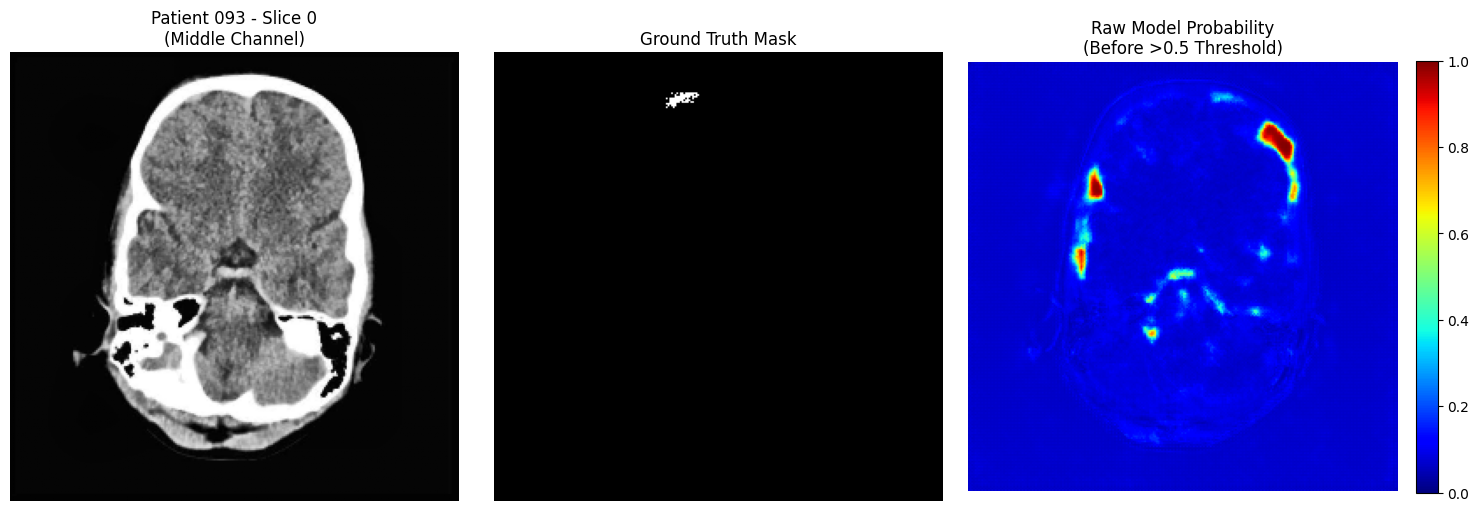

In [ ]:
import matplotlib.pyplot as plt

def debug_visualize_patient(model, dataset, patient_id):
    """Plots the Original Image, GT Mask, and Raw Model Probability Map"""
    model.eval()
    patient_df = dataset.df[dataset.df['patient_id'] == patient_id].reset_index(drop=True)

    # Find a slice that actually has a stroke mask (if it exists)
    slice_idx = 0
    for i in range(len(patient_df)):
        _, mask_tensor = dataset[i]
        if mask_tensor.sum() > 0:
            slice_idx = i
            break

    img_tensor, mask_tensor = dataset[slice_idx]

    with torch.no_grad():
        # Get raw probability
        prob_map = torch.sigmoid(model(img_tensor.unsqueeze(0).to(device)))
        prob_map = prob_map.squeeze().cpu().numpy()

    img_np = img_tensor.cpu().numpy()
    # Channel 2 is the 'current' slice in a 5-channel [m2, m1, curr, p1, p2] stack
    curr_slice_vis = img_np[2]
    mask_np = mask_tensor.squeeze().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(curr_slice_vis, cmap='gray')
    axes[0].set_title(f"Patient {patient_id} - Slice {slice_idx}\n(Middle Channel)")
    axes[0].axis('off')

    axes[1].imshow(mask_np, cmap='gray')
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')

    im = axes[2].imshow(prob_map, cmap='jet', vmin=0, vmax=1)
    axes[2].set_title("Raw Model Probability\n(Before >0.5 Threshold)")
    axes[2].axis('off')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# Load best model and visualize Patient 093 to debug 0.00 mL issue
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
debug_visualize_patient(model, val_ds, '093')
